# Автокорреляция и стационарность временных рядов

ACF измеряет связь ряда с его прошлыми значениями, а PACF — прямую связь с лагом после учёта промежуточных лагов. В ADF нулевая гипотеза означает наличие единичного корня, поэтому `p < 0.05` поддерживает стационарность. В KPSS нулевая гипотеза означает стационарность, поэтому `p >= 0.05` не даёт оснований её отвергать. Для логарифма цены используется константа и тренд (`ct`), для доходности — константа (`c`). Решения принимаются по train; validation и test используются только для описательной проверки устойчивости.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.tools.sm_exceptions import InterpolationWarning

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from analysis.loading import load_raw_snapshot  # noqa: E402
from analysis.preparation import DEFAULT_SPLIT_CONFIG  # noqa: E402
from analysis.quality import add_log_returns  # noqa: E402
from analysis.stationarity import (  # noqa: E402
    acf_pacf_table,
    build_stationarity_report,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## Данные и train-период

Структура временного ряда исследуется только на train. Первая доходность каждого тикера отсутствует по определению и удаляется внутри диагностических функций.

In [2]:
snapshot = load_raw_snapshot(PROJECT_ROOT / "data" / "raw")
returns = add_log_returns(snapshot.prices)
returns["log_price"] = np.log(returns["adj_close"])
train = returns.loc[
    returns["date"].between(
        DEFAULT_SPLIT_CONFIG.train_start,
        DEFAULT_SPLIT_CONFIG.train_end,
    )
].copy()
train.groupby("ticker").agg(
    observations=("log_return", "count"),
    first_date=("date", "min"),
    last_date=("date", "max"),
)

,observations,first_date,last_date
ticker,,,
AAPL,2516,2006-01-03,2015-12-31
JPM,2516,2006-01-03,2015-12-31
SPY,2516,2006-01-03,2015-12-31
XOM,2516,2006-01-03,2015-12-31


## ACF и PACF доходностей

Сильные отдельные пики могут подсказать кандидатов на лаги ARIMA, однако окончательный порядок модели будет выбираться только внутри train/validation-процедуры.

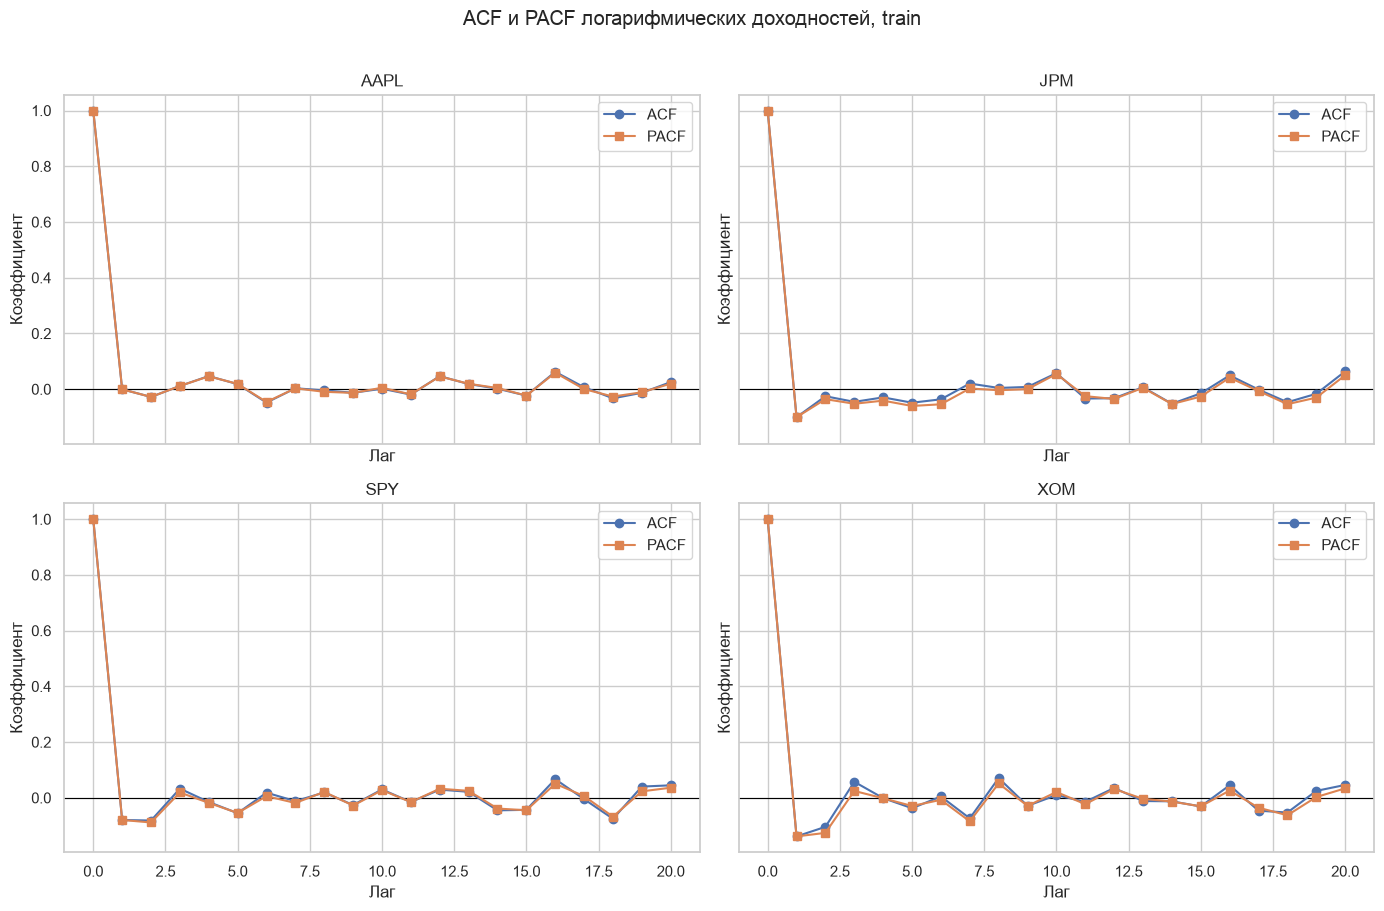

In [3]:
return_diagnostics = {
    str(ticker): acf_pacf_table(group["log_return"], nlags=20)
    for ticker, group in train.groupby("ticker", sort=True)
}
figure, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, (ticker, diagnostic) in zip(axes.flat, return_diagnostics.items(), strict=True):
    axis.axhline(0, color="black", linewidth=0.8)
    axis.plot(diagnostic["lag"], diagnostic["acf"], marker="o", label="ACF")
    axis.plot(
        diagnostic["lag"],
        diagnostic["pacf"],
        marker="s",
        label="PACF",
    )
    axis.set(title=ticker, xlabel="Лаг", ylabel="Коэффициент")
    axis.legend()
figure.suptitle("ACF и PACF логарифмических доходностей, train", y=1.01)
figure.tight_layout()
plt.show()

## ACF квадратов доходности

Положительная и медленно затухающая ACF квадратов доходности указывает на кластеризацию волатильности: крупные по модулю движения склонны группироваться во времени.

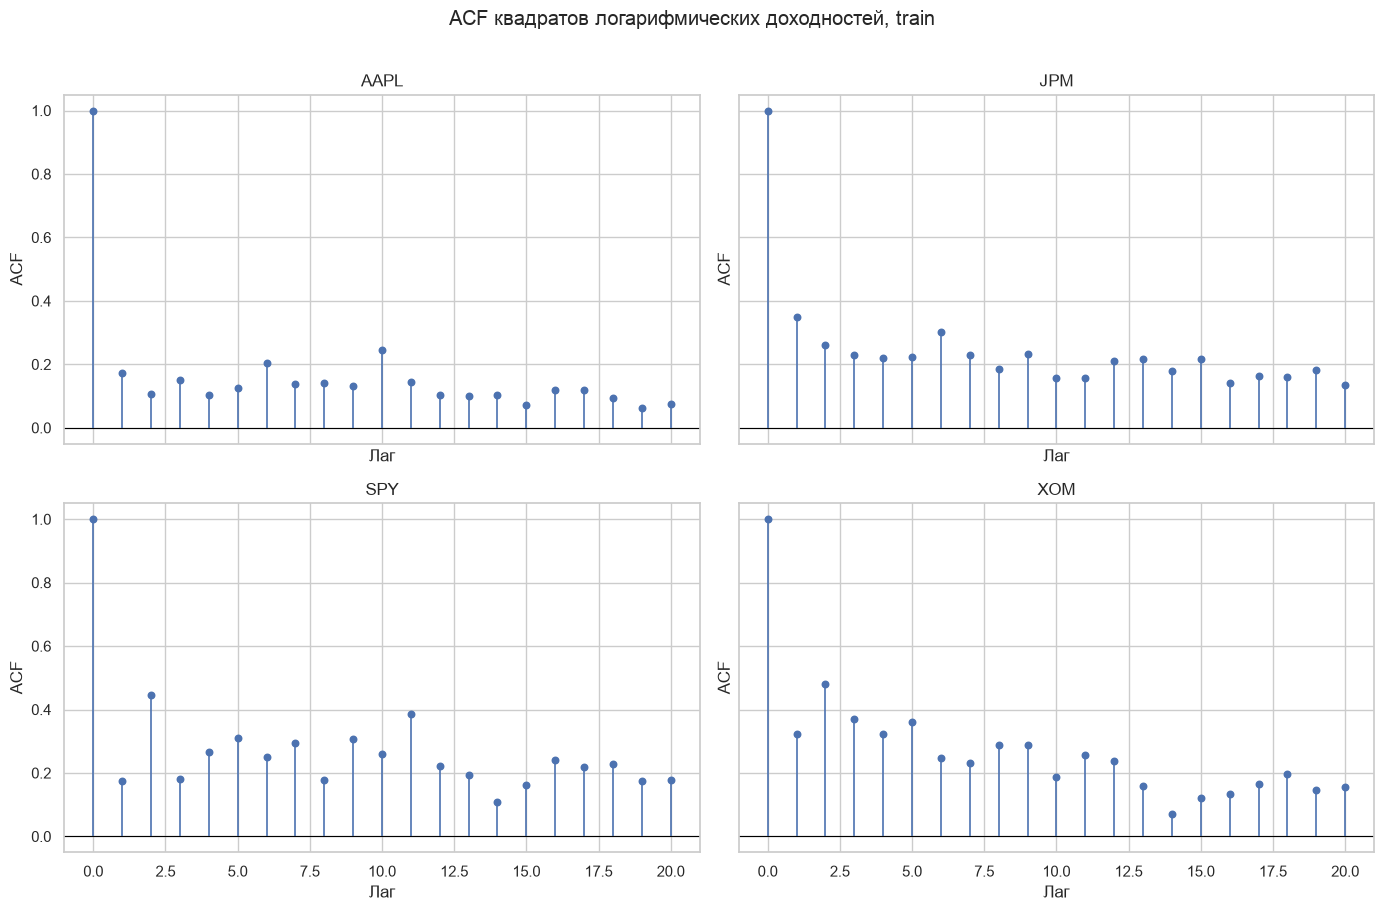

In [4]:
squared_diagnostics = {
    str(ticker): acf_pacf_table(group["log_return"].pow(2), nlags=20)
    for ticker, group in train.groupby("ticker", sort=True)
}
figure, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True, sharey=True)
for axis, (ticker, diagnostic) in zip(axes.flat, squared_diagnostics.items(), strict=True):
    axis.axhline(0, color="black", linewidth=0.8)
    axis.vlines(diagnostic["lag"], 0, diagnostic["acf"], linewidth=1.2)
    axis.scatter(diagnostic["lag"], diagnostic["acf"], s=22)
    axis.set(title=ticker, xlabel="Лаг", ylabel="ACF")
figure.suptitle("ACF квадратов логарифмических доходностей, train", y=1.01)
figure.tight_layout()
plt.show()

## ADF и KPSS на train

Значения `p_value` у KPSS могут совпадать с границами табличного диапазона statsmodels (0.01 или 0.10), поэтому они интерпретируются как неравенства, а не как точные вероятности.

In [5]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    stationarity_report = build_stationarity_report(train)
stationarity_report

,ticker,series,regression,test,statistic,p_value,lags,observations,critical_1pct,critical_5pct,critical_10pct,stationary_at_5pct
0,AAPL,log_price,ct,ADF,-2.283991,4.428242e-01,6,2510,-3.962381,-3.412241,-3.128081,False
1,AAPL,log_price,ct,KPSS,0.357763,1.000000e-02,30,2517,0.216000,0.146000,0.119000,False
2,AAPL,log_return,c,ADF,-20.560822,0.000000e+00,5,2510,-3.432958,-2.862692,-2.567383,True
3,AAPL,log_return,c,KPSS,0.067297,1.000000e-01,9,2516,0.739000,0.463000,0.347000,True
4,JPM,log_price,ct,ADF,-2.390038,3.849281e-01,26,2490,-3.962410,-3.412255,-3.128089,False
5,JPM,log_price,ct,KPSS,1.212500,1.000000e-02,30,2517,0.216000,0.146000,0.119000,False
6,JPM,log_return,c,ADF,-10.561472,7.708411e-19,27,2488,-3.432981,-2.862702,-2.567389,True
7,JPM,log_return,c,KPSS,0.057837,1.000000e-01,29,2516,0.739000,0.463000,0.347000,True
8,SPY,log_price,ct,ADF,-1.505401,8.272763e-01,22,2494,-3.962405,-3.412252,-3.128087,False
9,SPY,log_price,ct,KPSS,1.480621,1.000000e-02,30,2517,0.216000,0.146000,0.119000,False


In [6]:
train_decisions = stationarity_report.pivot(
    index=["ticker", "series"],
    columns="test",
    values="stationary_at_5pct",
)
train_p_values = stationarity_report.pivot(
    index=["ticker", "series"],
    columns="test",
    values="p_value",
)
display(train_decisions)
display(train_p_values.style.format("{:.4g}"))

test                 ADF   KPSS
ticker series                  
AAPL   log_price   False  False
       log_return   True   True
JPM    log_price   False  False
       log_return   True   True
SPY    log_price   False  False
       log_return   True   True
XOM    log_price   False  False
       log_return   True   True

## Описательная проверка validation и test

Результаты следующих периодов показываются как проверка устойчивости. Они не меняют решения, принятые по train.

In [7]:
sample_frames = {
    "train": train,
    "validation": returns.loc[
        returns["date"].between(
            DEFAULT_SPLIT_CONFIG.validation_start,
            DEFAULT_SPLIT_CONFIG.validation_end,
        )
    ],
    "test": returns.loc[
        returns["date"].between(
            DEFAULT_SPLIT_CONFIG.test_start,
            DEFAULT_SPLIT_CONFIG.test_end,
        )
    ],
}
with warnings.catch_warnings():
    warnings.simplefilter("ignore", InterpolationWarning)
    stability_report = pd.concat(
        [
            build_stationarity_report(frame).assign(sample=sample)
            for sample, frame in sample_frames.items()
        ],
        ignore_index=True,
    )
stability_decisions = stability_report.pivot(
    index=["ticker", "series", "test"],
    columns="sample",
    values="stationary_at_5pct",
).loc[:, ["train", "validation", "test"]]
stability_decisions

sample                  train  validation   test
ticker series     test                          
AAPL   log_price  ADF   False       False  False
                  KPSS  False       False  False
       log_return ADF    True        True   True
                  KPSS   True        True   True
JPM    log_price  ADF   False       False  False
                  KPSS  False       False  False
       log_return ADF    True        True   True
                  KPSS   True        True   True
SPY    log_price  ADF   False       False  False
                  KPSS  False       False  False
       log_return ADF    True        True   True
                  KPSS   True        True   True
XOM    log_price  ADF   False        True  False
                  KPSS  False       False  False
       log_return ADF    True        True   True
                  KPSS   True        True   True

In [8]:
autocorrelation_summary = pd.DataFrame(
    [
        {
            "ticker": ticker,
            "return_acf_lag1": return_diagnostics[ticker].loc[1, "acf"],
            "return_pacf_lag1": return_diagnostics[ticker].loc[1, "pacf"],
            "squared_return_acf_lag1": squared_diagnostics[ticker].loc[1, "acf"],
            "max_abs_return_acf_lags_1_20": (return_diagnostics[ticker].loc[1:, "acf"].abs().max()),
        }
        for ticker in return_diagnostics
    ]
).set_index("ticker")
autocorrelation_summary.style.format("{:.4f}")

,return_acf_lag1,return_pacf_lag1,squared_return_acf_lag1,max_abs_return_acf_lags_1_20
ticker,,,,
AAPL,-0.0004,-0.0004,0.1716,0.0622
JPM,-0.1006,-0.1006,0.3500,0.1006
SPY,-0.0796,-0.0796,0.1753,0.0816
XOM,-0.1385,-0.1385,0.3230,0.1385


## Выводы

- На train ADF и KPSS согласованно классифицируют логарифмы цен всех четырёх активов как нестационарные. Для ADF p-value лежит от 0.385 у JPM до 0.827 у SPY; KPSS для всех цен достигает нижней табличной границы p-value = 0.01.
- Логарифмические доходности, напротив, стационарны по обоим тестам для AAPL, JPM, SPY и XOM: ADF даёт p-value не выше 7.71e−19, а KPSS — верхнюю табличную границу 0.10. Поэтому дополнительное дифференцирование доходностей не требуется.
- Линейная автокорреляция доходностей невелика: ACF первого лага составляет −0.0004 для AAPL, −0.1006 для JPM, −0.0796 для SPY и −0.1385 для XOM. Это ограничивает ожидаемую силу чисто авторегрессионного сигнала.
- ACF первого лага квадратов доходности заметно выше: 0.172 для AAPL, 0.350 для JPM, 0.175 для SPY и 0.323 для XOM. Результат подтверждает кластеризацию волатильности и мотивирует отдельный анализ режимов риска.
- На validation и test вывод о стационарности доходностей сохраняется. Единственное расхождение возникает для логарифма цены XOM на validation: ADF поддерживает стационарность, а KPSS её отвергает. По заранее принятому правилу это не меняет решение train и трактуется как возможный эффект тренда или структурного сдвига.
- Основной объект моделирования — доходность следующего торгового дня, а не уровень цены. Порядки ARIMA нельзя выбирать только по этим графикам: кандидаты по ACF/PACF должны проверяться внутри train/validation без обращения к final test.